# Defining equations for lid cavity in 2D

## Continuity

$$

\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0 \\

$$

## Momentum balances in x and y directions

$$

\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = -\frac{\partial p}{\partial x} + \nu \left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right) \\

\frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = -\frac{\partial p}{\partial y} + \nu \left(\frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2}\right)

$$

## Boundary conditions

- At the lid (top boundary): $u(x, 1) = U$, $v(x, 1) = 0$
- At the bottom and side walls: $u = 0$, $v = 0$
- At the walls: $\frac{\partial p}{\partial n} = 0$ (no normal pressure gradient)

# Aim
We now have equations to describe the flow, so we can apply a general PINN to approximate the solutions for say, $u$ and $v$.
To find a loss function, we can use the residuals of the governing equations and the boundary conditions. The loss function can be defined as:

$$

\mathcal{R}_{\Omega} = \left(u u_x + v u_y + p_x - \frac{1}{Re}(u_{xx} + u_{yy})\right)^2 +
\left( u v_x + v v_y + p_y - \frac{1}{Re}(v_{xx} + v_{yy}) \right)^2 + \left( u_x + v_y \right)^2

$$

At the top boundary (lid):

$$

\mathcal{R}_{BC}^{top} = (u - 1)^2 + v^2

$$

At the bottom and side walls:

$$

\mathcal{R}_{BC}^{walls} = u^2 + v^2

$$

Thus, the total loss function can be defined as:

$$

\mathcal{L}
=
\int_{\Omega}
\left(
R_u^2 + R_v^2 + R_c^2
\right)\, d\Omega
+
\lambda_{BC}
\int_{\partial\Omega}
R_{BC}\, ds

$$

# Implementing a general PINN for the lid cavity problem



In [1]:
import torch
import torch.nn as nn

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reynolds number
Re = 100.0

In [2]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)  # outputs: u, v, p
        )

    def forward(self, x):
        return self.net(x)


model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [3]:
def interior_points(n):
    x = torch.rand(n, 1)
    y = torch.rand(n, 1)
    return torch.cat([x, y], dim=1).to(device)


def boundary_points(n):
    x = torch.rand(n, 1)
    y0 = torch.zeros(n, 1)
    y1 = torch.ones(n, 1)
    x0 = torch.zeros(n, 1)
    x1 = torch.ones(n, 1)

    top = torch.cat([x, y1], dim=1)
    bottom = torch.cat([x, y0], dim=1)
    left = torch.cat([x0, x], dim=1)
    right = torch.cat([x1, x], dim=1)

    return top.to(device), bottom.to(device), left.to(device), right.to(device)

In [4]:

def residual(xy):
    xy.requires_grad_(True)
    output = model(xy)
    u = output[:, 0:1]
    v = output[:, 1:2]
    p = output[:, 2:3]

    grads = torch.ones_like(u)

    # First derivatives
    u_x = torch.autograd.grad(u, xy, grads, retain_graph=True, create_graph=True)[0][:, 0:1]
    u_y = torch.autograd.grad(u, xy, grads, retain_graph=True, create_graph=True)[0][:, 1:2]
    v_x = torch.autograd.grad(v, xy, grads, retain_graph=True, create_graph=True)[0][:, 0:1]
    v_y = torch.autograd.grad(v, xy, grads, retain_graph=True, create_graph=True)[0][:, 1:2]
    p_x = torch.autograd.grad(p, xy, grads, retain_graph=True, create_graph=True)[0][:, 0:1]
    p_y = torch.autograd.grad(p, xy, grads, retain_graph=True, create_graph=True)[0][:, 1:2]

    # Second derivatives
    u_xx = torch.autograd.grad(u_x, xy, grads, retain_graph=True, create_graph=True)[0][:, 0:1]
    u_yy = torch.autograd.grad(u_y, xy, grads, retain_graph=True, create_graph=True)[0][:, 1:2]
    v_xx = torch.autograd.grad(v_x, xy, grads, retain_graph=True, create_graph=True)[0][:, 0:1]
    v_yy = torch.autograd.grad(v_y, xy, grads, retain_graph=True, create_graph=True)[0][:, 1:2]

    # Residuals
    R_u = u * u_x + v * u_y + p_x - (1/Re)*(u_xx + u_yy)
    R_v = u * v_x + v * v_y + p_y - (1/Re)*(v_xx + v_yy)
    R_c = u_x + v_y

    return R_u, R_v, R_c

In [14]:
n_int = 5000
n_bc = 1000

xy_int = interior_points(n_int)

top, bottom, left, right = boundary_points(n_bc)

optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=500,
    tolerance_grad=1e-9,
    tolerance_change=1e-9,
    history_size=100,
    line_search_fn="strong_wolfe"
)

def closure():
    optimizer.zero_grad()

    # Interior residual
    R_u, R_v, R_c = residual(xy_int)
    loss_int = torch.mean(R_u**2 + R_v**2 + R_c**2)

    # Top lid (u=1, v=0)
    out_top = model(top)
    loss_top = torch.mean((out_top[:, 0:1] - 1)**2 + out_top[:, 1:2]**2)

    # Other walls (u=0, v=0)
    out_bottom = model(bottom)
    out_left = model(left)
    out_right = model(right)

    loss_walls = (
        torch.mean(out_bottom[:, 0:1]**2 + out_bottom[:, 1:2]**2) +
        torch.mean(out_left[:, 0:1]**2 + out_left[:, 1:2]**2) +
        torch.mean(out_right[:, 0:1]**2 + out_right[:, 1:2]**2)
    )

    # Optional: Pressure pinning for stability
    xy_ref = torch.tensor([[0.0, 0.0]], dtype=torch.float32).to(next(model.parameters()).device)
    p_ref = model(xy_ref)[0, 2]
    loss_pressure = p_ref**2

    loss = loss_int + 100*(loss_top + loss_walls) + loss_pressure

    loss.backward()

    print("Loss:", loss.item())
    print("Continuity residual:", torch.mean(R_c**2).item())

    return loss

print("Starting LBFGS optimization...")
optimizer.step(closure)
print("LBFGS complete.")

Starting LBFGS optimization...
Loss: 4.378466606140137
Continuity residual: 0.06977944076061249
Loss: 23.063425064086914
Continuity residual: 0.12709489464759827
Loss: 4.284324645996094
Continuity residual: 0.07207068800926208
Loss: 4.259980201721191
Continuity residual: 0.07199854403734207
Loss: 4.067127227783203
Continuity residual: 0.07136090099811554
Loss: 3.412984848022461
Continuity residual: 0.07582814246416092
Loss: 3.28317928314209
Continuity residual: 0.06912989914417267
Loss: 3.057582139968872
Continuity residual: 0.07009003311395645
Loss: 2.9333815574645996
Continuity residual: 0.07132602483034134
Loss: 2.811762809753418
Continuity residual: 0.07262640446424484
Loss: 2.6519503593444824
Continuity residual: 0.07441326975822449
Loss: 2.1648268699645996
Continuity residual: 0.08094589412212372
Loss: 9.560315132141113
Continuity residual: 0.09765313565731049
Loss: 2.0899808406829834
Continuity residual: 0.08225510269403458
Loss: 1.7625579833984375
Continuity residual: 0.0884968

# Analysing the results with plots

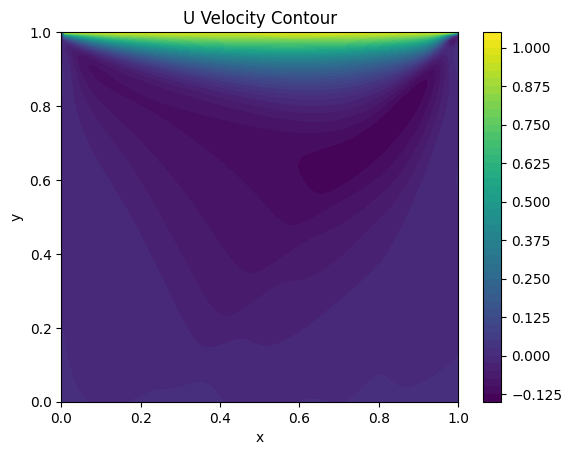

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure model is in evaluation mode
model.eval()

# Grid resolution
N = 100
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

# Prepare input tensor
XY = torch.tensor(
    np.vstack([X.flatten(), Y.flatten()]).T,
    dtype=torch.float32
)

with torch.no_grad():
    pred = model(XY.to(next(model.parameters()).device)).cpu().numpy()

u = pred[:, 0].reshape(N, N)
v = pred[:, 1].reshape(N, N)
p = pred[:, 2].reshape(N, N)

velocity_magnitude = np.sqrt(u**2 + v**2)

# 1. U-velocity contour
plt.figure()
plt.contourf(X, Y, u, 50)
plt.colorbar()
plt.title("U Velocity Contour")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

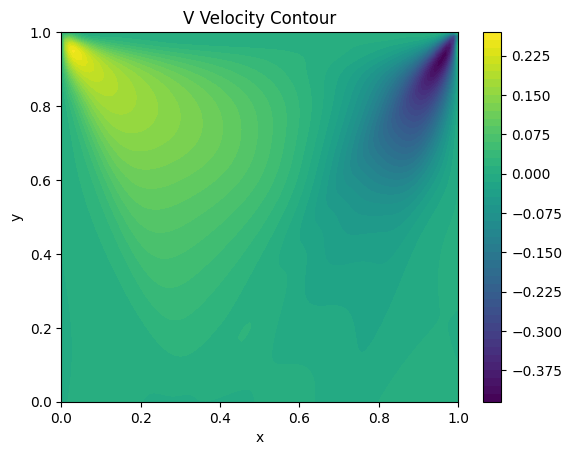

In [16]:
# ==========================
# 2. V-velocity contour
# ==========================
plt.figure()
plt.contourf(X, Y, v, 50)
plt.colorbar()
plt.title("V Velocity Contour")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

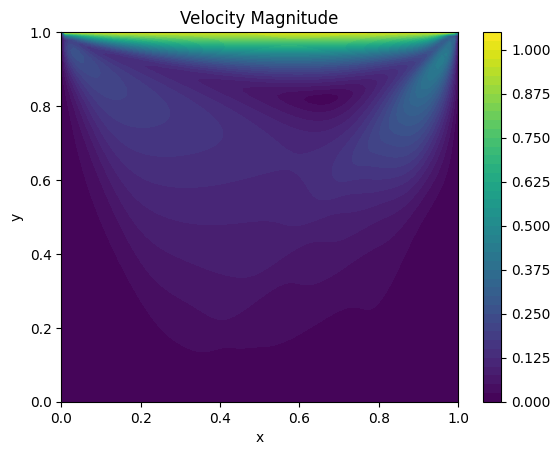

In [17]:
# ==========================
# 3. Velocity Magnitude
# ==========================
plt.figure()
plt.contourf(X, Y, velocity_magnitude, 50)
plt.colorbar()
plt.title("Velocity Magnitude")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

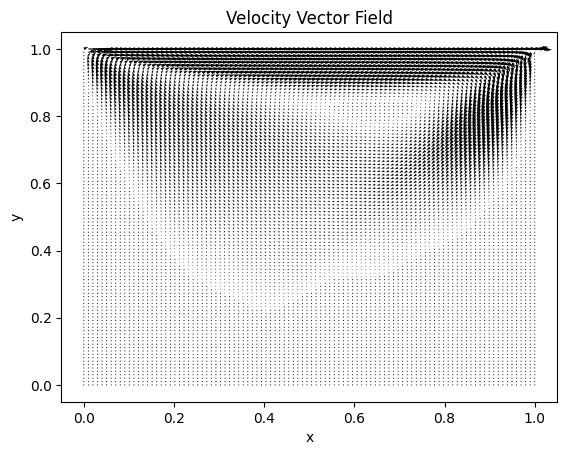

In [18]:
# ==========================
# 4. Velocity Vector Field
# ==========================
plt.figure()
plt.quiver(X, Y, u, v)
plt.title("Velocity Vector Field")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

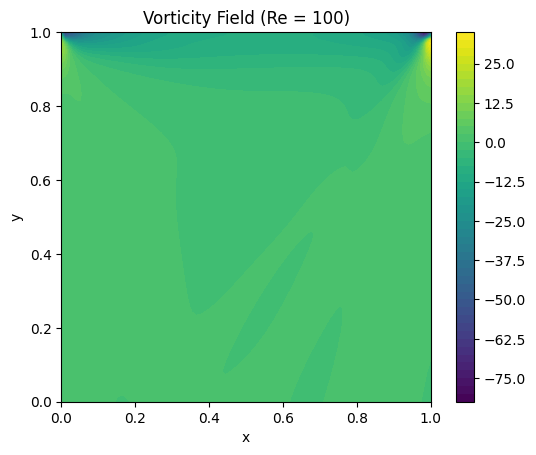

In [19]:
dx = x[1] - x[0]
dy = y[1] - y[0]

v_x = np.gradient(v, dx, axis=1)
u_y = np.gradient(u, dy, axis=0)

omega = v_x - u_y

# ==========================
# 5. Plot Vorticity
# ==========================
plt.figure()
plt.contourf(X, Y, omega, 50)
plt.colorbar()
plt.title("Vorticity Field (Re = 100)")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect('equal')
plt.show()